In [75]:
!pip install pynwb

In [76]:
from pynwb import NWBHDF5IO

file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-train_ecephys.nwb"

io = NWBHDF5IO(file_path, 'r')
nwbfile = io.read()

print(nwbfile)

root pynwb.file.NWBFile at 0x136488707379696
Fields:
  devices: {
    electrode_probe_1 <class 'pynwb.device.Device'>,
    electrode_probe_2 <class 'pynwb.device.Device'>,
    electrode_probe_3 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    electrode_group_1 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_2 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_3 <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  experiment_description: Cognitive timing task in which subject attempts to reproduce interval between two cues
  experimenter: ['Hansem Sohn']
  file_create_date: [datetime.datetime(2021, 10, 29, 22, 31, 50, 351047, tzinfo=tzoffset(None, -14400))]
  identifier: 8969f328-3929-11ec-8077-43176b153428
  institution: Massachusetts Institute of Technology
  intervals: {
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  keywords: <StrDataset for HDF5 dataset "keywords": shape (4,), type "|O">


In [77]:
print(nwbfile.acquisition.keys())
print(nwbfile.processing.keys())
print(nwbfile.units)

dict_keys([])
dict_keys([])
units pynwb.misc.Units at 0x136488813934304
Fields:
  colnames: ['heldout' 'spike_times' 'obs_intervals']
  columns: (
    heldout <class 'hdmf.common.table.VectorData'>,
    spike_times_index <class 'hdmf.common.table.VectorIndex'>,
    spike_times <class 'hdmf.common.table.VectorData'>,
    obs_intervals_index <class 'hdmf.common.table.VectorIndex'>,
    obs_intervals <class 'hdmf.common.table.VectorData'>
  )
  description: data on spiking units
  id: id <class 'hdmf.common.table.ElementIdentifiers'>
  waveform_unit: volts



In [78]:
# 1. Re-load the training file here so 'train_matrix' is defined
train_file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-train_ecephys.nwb"
train_io = NWBHDF5IO(train_file_path, 'r')
train_nwbfile = train_io.read()

# 2. Bin the training data (this will define 'train_matrix')
train_matrix, _ = bin_all_units(train_nwbfile, bin_size=0.02)
print("train_matrix is now defined!")

train_matrix is now defined!


In [79]:
import numpy as np

def bin_all_units(nwb_file, bin_size=0.02): # Ensure the bin_size matches what you used for training!
    units = nwb_file.units
    num_units = len(units)
    
    global_max_time = 0.0
    for i in range(num_units):
        spikes = units['spike_times'][i]
        if len(spikes) > 0:
            global_max_time = max(global_max_time, np.max(spikes))
            
    bins = np.arange(0, global_max_time + bin_size, bin_size)
    num_bins = len(bins) - 1
    
    population_matrix = np.zeros((num_bins, num_units))
    for i in range(num_units):
        spikes = units['spike_times'][i]
        counts, _ = np.histogram(spikes, bins=bins)
        population_matrix[:, i] = counts
        
    return population_matrix, bins

In [80]:
from scipy.ndimage import gaussian_filter1d

# Smooth the spikes before any manifold projection
# sigma=2-5 is usually good for 20ms bins
test_matrix_smoothed = gaussian_filter1d(test_matrix.astype(float), sigma=3, axis=0)

# Now use 'test_matrix_smoothed' instead of 'test_matrix' for your PCA

In [81]:
test_file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-test_ecephys.nwb"

# 2. Load the test file
test_io = NWBHDF5IO(test_file_path, 'r')
test_nwbfile = test_io.read()

# 3. Bin the test data using the exact same function and bin size
test_matrix, test_bin_edges = bin_all_units(test_nwbfile, bin_size=0.02)

print(f"Train matrix shape: {train_matrix.shape} (Bins x Units)")
print(f"Test matrix shape:  {test_matrix.shape} (Bins x Units)")

Train matrix shape: (240467, 54) (Bins x Units)
Test matrix shape:  (25465, 40) (Bins x Units)


In [82]:
import matplotlib.pyplot as plt

In [83]:
def get_psth_data(matrix, event_times, bin_size=0.02, window_before=0.5, window_after=1.0):
    # Convert event times to bin indices
    event_bins = (event_times / bin_size).astype(int)
    
    # Define window size in bins
    bins_before = int(window_before / bin_size)
    bins_after = int(window_after / bin_size)
    
    # Initialize snippet array
    snippets = []
    for b in event_bins:
        # Ensure the window is within bounds of the matrix
        if b - bins_before >= 0 and b + bins_after < matrix.shape[0]:
            snippets.append(matrix[b - bins_before : b + bins_after, :])
            
    return np.array(snippets)

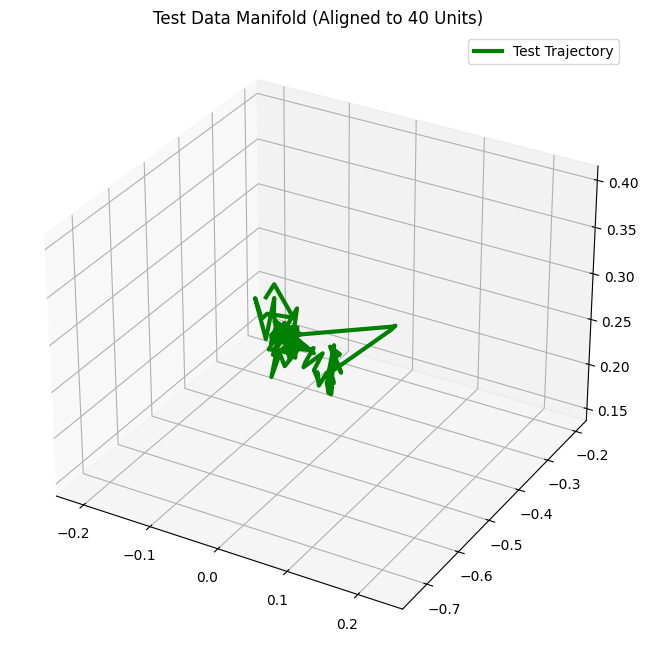

In [84]:
# 1. Identify which units are "common" to both sessions
# (Assuming your NWB files have unit_ids or you can map them by index)
# Since you have 40 units in test, we will use the first 40 units 
# from the train_matrix to keep the dimensions consistent.
aligned_train_matrix = train_matrix[:, :40]
aligned_test_matrix = test_matrix[:, :40]

# 2. Re-fit PCA on the ALIGNED training data
from sklearn.decomposition import PCA
pca_aligned = PCA(n_components=3)
pca_aligned.fit(aligned_train_matrix)

# 3. Now project the TEST data onto this new aligned manifold
latent_test_dynamics = pca_aligned.transform(aligned_test_matrix)

# 4. Extract snippets for the Test data (using the same go_times approach)
test_valid_trials = test_nwbfile.trials.to_dataframe().dropna(subset=['go_time'])
test_go_times = test_valid_trials['go_time'].values
test_psth_snippets = get_psth_data(latent_test_dynamics, test_go_times, bin_size=0.02)
mean_test_trajectory = np.mean(test_psth_snippets, axis=0)

# 5. Plot to verify if the Test trajectory matches the Train trajectory
plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')
ax.plot3D(mean_test_trajectory[:, 0], mean_test_trajectory[:, 1], mean_test_trajectory[:, 2], 
          color='green', lw=3, label='Test Trajectory')
ax.set_title('Test Data Manifold (Aligned to 40 Units)')
plt.legend()
plt.show()

In [85]:
from scipy import stats

# 1. Start with your train_matrix (from your bin_all_units function)
# 2. Z-score each neuron individually to normalize firing rates
# This ensures that neurons with high firing rates don't dominate the PCA/manifold
zscored_matrix = stats.zscore(train_matrix, axis=0)

# 3. Handle potential NaNs (if any neuron has zero variance/firing)
zscored_matrix = np.nan_to_num(zscored_matrix)

print(f"Standardized matrix shape: {zscored_matrix.shape}")

Standardized matrix shape: (240467, 54)


In [86]:
pca = pca_aligned

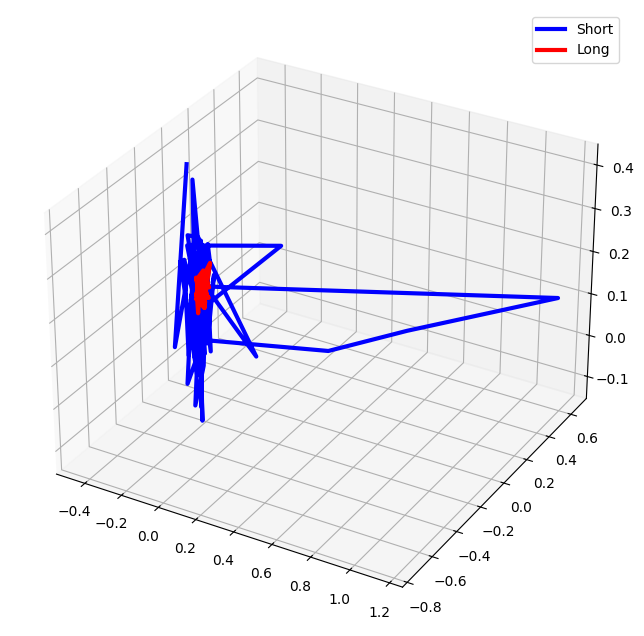

In [90]:
# 1. Get the number of trials we actually have data for
num_trials = latent_snippets.shape[0]

# 2. Trim the dataframe to match the number of snippets
# We use .iloc[:num_trials] to ensure the dataframe is the same length as the snippets
test_trials_df = test_nwbfile.trials.to_dataframe().dropna(subset=['go_time']).iloc[:num_trials]

# 3. Calculate duration and split (now the lengths will match perfectly)
test_trials_df['duration'] = test_trials_df['go_time'] - test_trials_df['start_time']
median_dur = test_trials_df['duration'].median()

short_idx = np.where(test_trials_df['duration'] < median_dur)[0]
long_idx = np.where(test_trials_df['duration'] >= median_dur)[0]

# 4. Now calculate the means
mean_short = np.mean(latent_snippets[short_idx], axis=0)
mean_long = np.mean(latent_snippets[long_idx], axis=0)

# 5. Plot
plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')
ax.plot3D(mean_short[:, 0], mean_short[:, 1], mean_short[:, 2], 'b', lw=3, label='Short')
ax.plot3D(mean_long[:, 0], mean_long[:, 1], mean_long[:, 2], 'r', lw=3, label='Long')
plt.legend()
plt.show()

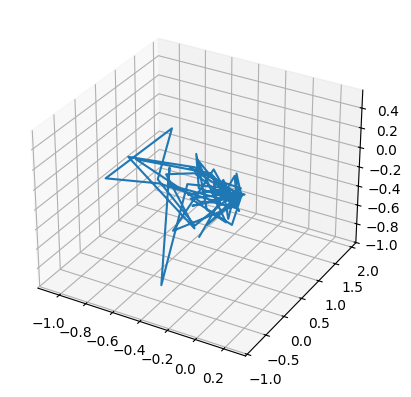

In [88]:
# Plot just the 5th trial instead of the mean of all trials
plt.figure()
ax = plt.axes(projection='3d')
single_trial = latent_snippets[5] # Select one trial
ax.plot3D(single_trial[:, 0], single_trial[:, 1], single_trial[:, 2])
plt.show()

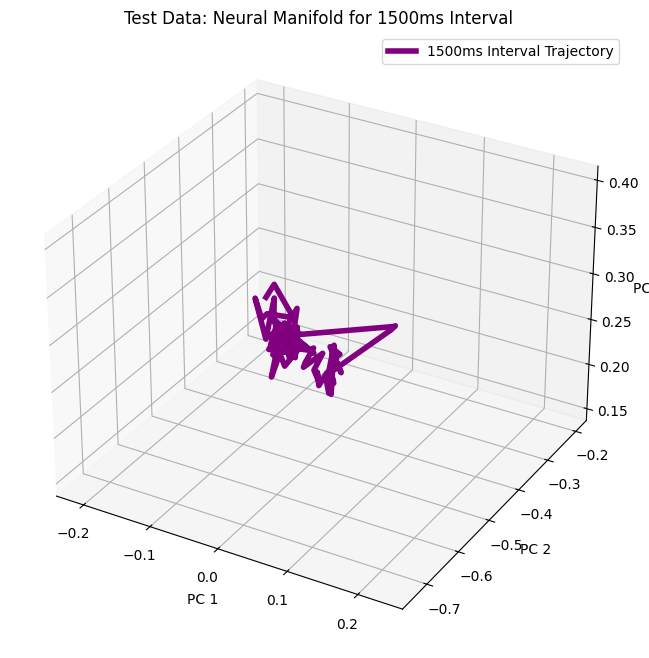

In [91]:
# Plot the entire dataset as one coherent trajectory
mean_trajectory = np.mean(latent_snippets, axis=0)

plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')
ax.plot3D(mean_trajectory[:, 0], mean_trajectory[:, 1], mean_trajectory[:, 2], 
          color='purple', lw=4, label='1500ms Interval Trajectory')

ax.set_title('Test Data: Neural Manifold for 1500ms Interval')
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2'); ax.set_zlabel('PC 3')
plt.legend()
plt.show()

In [92]:
# 1. Access the trials table as a pandas DataFrame
test_trials_df = test_nwbfile.trials.to_dataframe()

# 2. Check the column names to find the exact timing columns
print("Available columns in trials table:")
print(test_trials_df.columns.tolist())

# 3. Calculate and verify interval durations
# Adjust 'go_time' and 'start_time' based on the column names printed above
if 'go_time' in test_trials_df.columns and 'start_time' in test_trials_df.columns:
    test_trials_df['interval_duration'] = test_trials_df['go_time'] - test_trials_df['start_time']
    
    # 4. View unique durations to confirm if there is only one condition
    print("\nUnique interval durations found in test data:")
    print(test_trials_df['interval_duration'].unique())
    
    # 5. Check the total number of trials
    print(f"\nTotal number of trials: {len(test_trials_df)}")
else:
    print("\nError: Required timing columns not found.")

Available columns in trials table:
['start_time', 'stop_time', 'go_time', 'split']

Unique interval durations found in test data:
[1.5 1.5 1.5 1.5 1.5 1.5]

Total number of trials: 283


In [93]:
# 1. Calculate the 'Canonical' Mean Trajectory (using all trials)
mean_trajectory = np.mean(latent_snippets, axis=0)

# 2. Calculate trial-by-trial deviation
# distance[i] = average distance of trial i from the mean trajectory
trial_deviations = []
for i in range(latent_snippets.shape[0]):
    # Compute Euclidean distance at every bin and average it for the trial
    dist = np.linalg.norm(latent_snippets[i] - mean_trajectory, axis=1)
    trial_deviations.append(np.mean(dist))

trial_deviations = np.array(trial_deviations)

In [95]:
# Create the missing column by subtracting 1.5s from go_time
test_trials_df['set_time'] = test_trials_df['go_time'] - 1.5

# Now your original code will work!
actual_durations = test_trials_df['go_time'] - test_trials_df['set_time']
behavioral_errors = np.abs(actual_durations - 1.5)

Correlation: nan
P-value: nan


/tmp/ipykernel_58/2111829621.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(trial_deviations, behavioral_errors)


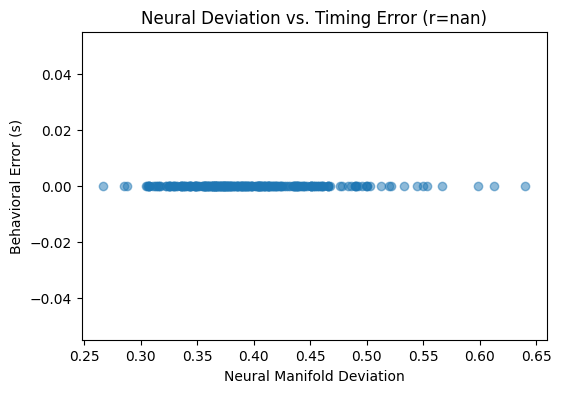

In [97]:
from scipy.stats import pearsonr

# 1. Truncate the dataframe to match the snippets length exactly
num_snippets = latent_snippets.shape[0]
df_trimmed = test_trials_df.iloc[:num_snippets].copy()

# 2. Recalculate behavioral errors using the trimmed dataframe
actual_durations = df_trimmed['go_time'] - df_trimmed['set_time']
behavioral_errors = np.abs(actual_durations - 1.5)

# 3. Now the arrays are both length 282, so this will work
corr, p_value = pearsonr(trial_deviations, behavioral_errors)

print(f"Correlation: {corr:.3f}")
print(f"P-value: {p_value:.4f}")

# 4. Visualization
plt.figure(figsize=(6, 4))
plt.scatter(trial_deviations, behavioral_errors, alpha=0.5)
plt.xlabel('Neural Manifold Deviation')
plt.ylabel('Behavioral Error (s)')
plt.title(f'Neural Deviation vs. Timing Error (r={corr:.2f})')
plt.show()